In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import statistics as sts 
import streamlit as st 
from matplotlib import pyplot as plt 
from sklearn.preprocessing import PowerTransformer,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import cross_val_score,GridSearchCV,train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,confusion_matrix,classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,f_classif
import joblib 
import warnings
import time 
import traceback


In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\pred10\customer_churn_dataset-testing-master.csv\customer_churn_dataset-testing-master.csv",encoding_errors='ignore')

In [3]:
df2=df1.copy()

In [4]:
def sample_operations(df2):
    print(df2.ndim)
    print(df2.shape)
    print(df2.size)
    print("============================================")
    print(df2.isna().sum())
    print("============================================")
    print(df2.isnull().sum())

sample_operations(df2)

2
(64374, 12)
772488
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [5]:
def dropping_duplicates(df2):
    df2.drop_duplicates()

dropping_duplicates(df2)

In [6]:
def columsn_devide(df2):
    numeric_col=df2.select_dtypes(include='number',exclude='object')
    cata_col=df2.select_dtypes(include='object',exclude='number')
    return numeric_col.columns,cata_col.columns
numeric,catage=columsn_devide(df2)
print(f"numeric columsn : ---> {numeric.to_list()}")
print(f"catagerical columns are  : ----> {catage.to_list()}")

numeric columsn : ---> ['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']
catagerical columns are  : ----> ['Gender', 'Subscription Type', 'Contract Length']


In [7]:
df2[['Gender','Subscription Type','Contract Length']].value_counts().to_dict()

{('Female', 'Premium', 'Monthly'): 4101,
 ('Female', 'Standard', 'Monthly'): 4082,
 ('Female', 'Basic', 'Monthly'): 4065,
 ('Female', 'Basic', 'Quarterly'): 3772,
 ('Female', 'Standard', 'Annual'): 3711,
 ('Female', 'Basic', 'Annual'): 3696,
 ('Female', 'Premium', 'Annual'): 3683,
 ('Female', 'Premium', 'Quarterly'): 3643,
 ('Female', 'Standard', 'Quarterly'): 3600,
 ('Male', 'Standard', 'Annual'): 3476,
 ('Male', 'Basic', 'Annual'): 3452,
 ('Male', 'Premium', 'Annual'): 3392,
 ('Male', 'Standard', 'Quarterly'): 3367,
 ('Male', 'Basic', 'Monthly'): 3308,
 ('Male', 'Premium', 'Monthly'): 3308,
 ('Male', 'Premium', 'Quarterly'): 3294,
 ('Male', 'Standard', 'Monthly'): 3266,
 ('Male', 'Basic', 'Quarterly'): 3158}

In [8]:
Label_enocder=LabelEncoder()
df2['Gender_encoded']=Label_enocder.fit_transform(df2['Gender'])

In [9]:
df2['Subscription_Type_encoded']=Label_enocder.fit_transform(df2['Subscription Type'])

In [10]:
df2['Contract_Length_encoded'] = Label_enocder.fit_transform(df2['Contract Length'])

In [11]:
df2.sample(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_encoded,Subscription_Type_encoded,Contract_Length_encoded
55869,55870,59,Male,42,13,7,19,Premium,Monthly,784,12,1,1,1,1
42242,42243,44,Male,47,5,0,8,Premium,Monthly,559,16,0,1,1,1
33439,33440,45,Male,19,8,3,0,Premium,Quarterly,681,1,0,1,1,2
60744,60745,60,Female,17,5,0,23,Premium,Quarterly,496,24,1,0,1,2
4030,4031,62,Male,9,12,2,17,Basic,Monthly,163,28,0,1,0,1
9978,9979,34,Male,45,28,2,12,Basic,Monthly,566,11,0,1,0,1
59337,59338,40,Male,46,14,7,23,Premium,Monthly,816,22,1,1,1,1
18754,18755,24,Female,40,26,4,25,Basic,Annual,587,28,0,0,0,0
16072,16073,20,Male,23,16,0,28,Basic,Monthly,155,14,0,1,0,1
50260,50261,29,Female,15,1,5,14,Standard,Annual,213,2,1,0,2,0


In [12]:
spearman=df2[numeric].corr(method='spearman').round(2)
print(spearman)

                  CustomerID   Age  Tenure  Usage Frequency  Support Calls  \
CustomerID              1.00  0.04    0.10            -0.06           0.16   
Age                     0.04  1.00   -0.01            -0.04           0.00   
Tenure                  0.10 -0.01    1.00             0.02           0.06   
Usage Frequency        -0.06 -0.04    0.02             1.00          -0.01   
Support Calls           0.16  0.00    0.06            -0.01           1.00   
Payment Delay           0.29 -0.02    0.05             0.03           0.06   
Total Spend            -0.04  0.01    0.01             0.00           0.02   
Last Interaction       -0.00 -0.00    0.01            -0.01           0.00   
Churn                   0.53  0.06    0.19            -0.12           0.30   

                  Payment Delay  Total Spend  Last Interaction  Churn  
CustomerID                 0.29        -0.04             -0.00   0.53  
Age                       -0.02         0.01             -0.00   0.06  
Ten

In [13]:
spearman=df2[numeric].corr(method='pearson').round(2)
print(spearman)

                  CustomerID   Age  Tenure  Usage Frequency  Support Calls  \
CustomerID              1.00  0.04    0.10            -0.06           0.16   
Age                     0.04  1.00   -0.01            -0.04           0.01   
Tenure                  0.10 -0.01    1.00             0.02           0.06   
Usage Frequency        -0.06 -0.04    0.02             1.00          -0.01   
Support Calls           0.16  0.01    0.06            -0.01           1.00   
Payment Delay           0.29 -0.02    0.06             0.03           0.06   
Total Spend            -0.04  0.01    0.01             0.00           0.02   
Last Interaction       -0.00 -0.00    0.01            -0.01           0.00   
Churn                   0.53  0.06    0.20            -0.12           0.30   

                  Payment Delay  Total Spend  Last Interaction  Churn  
CustomerID                 0.29        -0.04             -0.00   0.53  
Age                       -0.02         0.01             -0.00   0.06  
Ten

In [14]:
df3=df2.copy()

In [15]:
df3.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn',
       'Gender_encoded', 'Subscription_Type_encoded',
       'Contract_Length_encoded'],
      dtype='object')

In [16]:
df3.drop(columns=['Contract Length','Gender','Contract Length'],axis=1,inplace=True)

In [17]:
df3.drop(columns=['CustomerID'],axis=1,inplace=True)

In [18]:
df3.sample(10)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Gender_encoded,Subscription_Type_encoded,Contract_Length_encoded
50661,59,45,5,5,6,Basic,168,18,1,1,0,0
52545,46,16,13,9,22,Basic,450,15,1,0,0,0
55161,47,6,1,10,21,Basic,129,10,1,0,0,2
6298,18,43,5,7,17,Standard,618,6,1,1,2,0
4847,52,45,12,6,12,Standard,683,26,0,1,2,0
62505,61,53,26,8,17,Premium,854,4,1,0,1,0
14704,61,43,27,1,24,Basic,559,29,0,1,0,0
41563,18,47,22,1,29,Premium,843,28,0,1,1,2
22727,54,36,27,6,14,Basic,784,8,0,1,0,2
7303,53,60,25,6,8,Basic,150,2,0,0,0,0


In [19]:
df3.columns

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Subscription Type', 'Total Spend', 'Last Interaction', 'Churn',
       'Gender_encoded', 'Subscription_Type_encoded',
       'Contract_Length_encoded'],
      dtype='object')

In [20]:
df3=pd.DataFrame(data=df3,columns=['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Subscription Type', 'Total Spend', 'Last Interaction',
       'Gender_encoded', 'Subscription_Type_encoded',
       'Contract_Length_encoded', 'Churn'])

In [21]:
df3.sample(10)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Gender_encoded,Subscription_Type_encoded,Contract_Length_encoded,Churn
30349,54,25,8,8,26,Basic,136,9,1,0,1,1
32288,42,58,28,10,23,Basic,662,13,1,0,1,1
1928,42,14,14,1,19,Standard,982,1,0,2,2,0
11120,54,38,5,1,28,Basic,221,21,1,0,2,0
30397,19,5,28,1,21,Standard,125,28,1,2,0,0
4485,29,54,13,1,15,Standard,437,3,0,2,1,0
54865,24,60,15,8,24,Premium,258,29,1,1,0,1
41912,49,30,27,3,29,Standard,692,19,1,2,0,0
35151,32,9,23,7,14,Standard,511,22,0,2,2,0
9928,39,25,9,9,13,Standard,630,23,0,2,2,0


In [22]:
class Anomolies_detection:
    def __init__(self,data):
        self.data=data
    def anomolies_function(self,column):
        Q1=self.data[column].quantile(0.25)
        Q3=self.data[column].quantile(0.75)
        IQR=Q3-Q1 
        left_bound=Q1-1.5*IQR
        right_bound=Q3+1.5*IQR 
        mask= (self.data[column]< left_bound) | (self.data[column]>right_bound)
        anomolies_indexes=self.data[mask].index.to_list()
        anomolies_data =self.data[column][mask].to_list()
        return anomolies_indexes,list(anomolies_data)
  
selected_numeric_columns=df3.select_dtypes(include='number').columns
Anomolies_detection_instance=Anomolies_detection(df3)
anomolies_indexes_store=set()
for each_column in selected_numeric_columns:
    anomolies_index,anomolies_data=Anomolies_detection_instance.anomolies_function(each_column)
    counting_indexes=len(anomolies_index)
    if anomolies_index:
        print(f" {each_column} ---> data {anomolies_data} and indexes: {anomolies_index}  and count is  {counting_indexes}")
        print(f"{anomolies_index}")
        time.sleep(3)
        anomolies_indexes_store.update(anomolies_index)
    else:
        print(f"{each_column} no anomolies data")


df4=df3.drop(list(anomolies_indexes_store),axis=0)
print(f"old shape is {df3.shape} ------ new shape {df4.shape}")

Age no anomolies data
Tenure no anomolies data
Usage Frequency no anomolies data
Support Calls no anomolies data
Payment Delay no anomolies data
Total Spend no anomolies data
Last Interaction no anomolies data
Gender_encoded no anomolies data
Subscription_Type_encoded no anomolies data
Contract_Length_encoded no anomolies data
Churn no anomolies data
old shape is (64374, 12) ------ new shape (64374, 12)


In [23]:
df4.sample(10)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Gender_encoded,Subscription_Type_encoded,Contract_Length_encoded,Churn
2726,22,47,13,9,27,Premium,874,7,1,1,2,1
10695,60,16,4,8,3,Standard,797,9,0,2,1,1
1053,36,59,9,1,16,Standard,889,5,0,2,2,0
45969,33,30,27,9,28,Premium,471,17,1,1,1,1
22389,26,44,28,7,10,Standard,809,5,1,2,0,0
22619,64,19,27,5,26,Basic,848,19,1,0,0,0
38228,59,58,23,1,13,Standard,950,28,1,2,2,0
25717,55,6,27,8,0,Standard,764,16,0,2,2,0
18077,21,31,18,7,1,Standard,504,30,0,2,1,0
54571,48,13,26,2,24,Standard,247,6,0,2,1,1


In [24]:
df4.columns

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Subscription Type', 'Total Spend', 'Last Interaction',
       'Gender_encoded', 'Subscription_Type_encoded',
       'Contract_Length_encoded', 'Churn'],
      dtype='object')

In [25]:
df4.drop(columns=["Subscription Type"],axis=1,inplace=True)

In [26]:
df4.rename(columns={"Usage Frequency":"UsageFrequency","Support Calls":"SupportCalls","Total Spend":"TotalSpend","Last Interaction":"LastInteraction"},inplace=True)

In [27]:
df4.rename(columns={"Subscription_Type_encoded":"SubscriptionTypeencoded","Gender_encoded":"Genderencoded","Contract_Length_encoded":"ContractLengthencoded"},inplace=True)

In [28]:
df4.rename(columns={'Payment Delay':"Payements"},inplace=True)

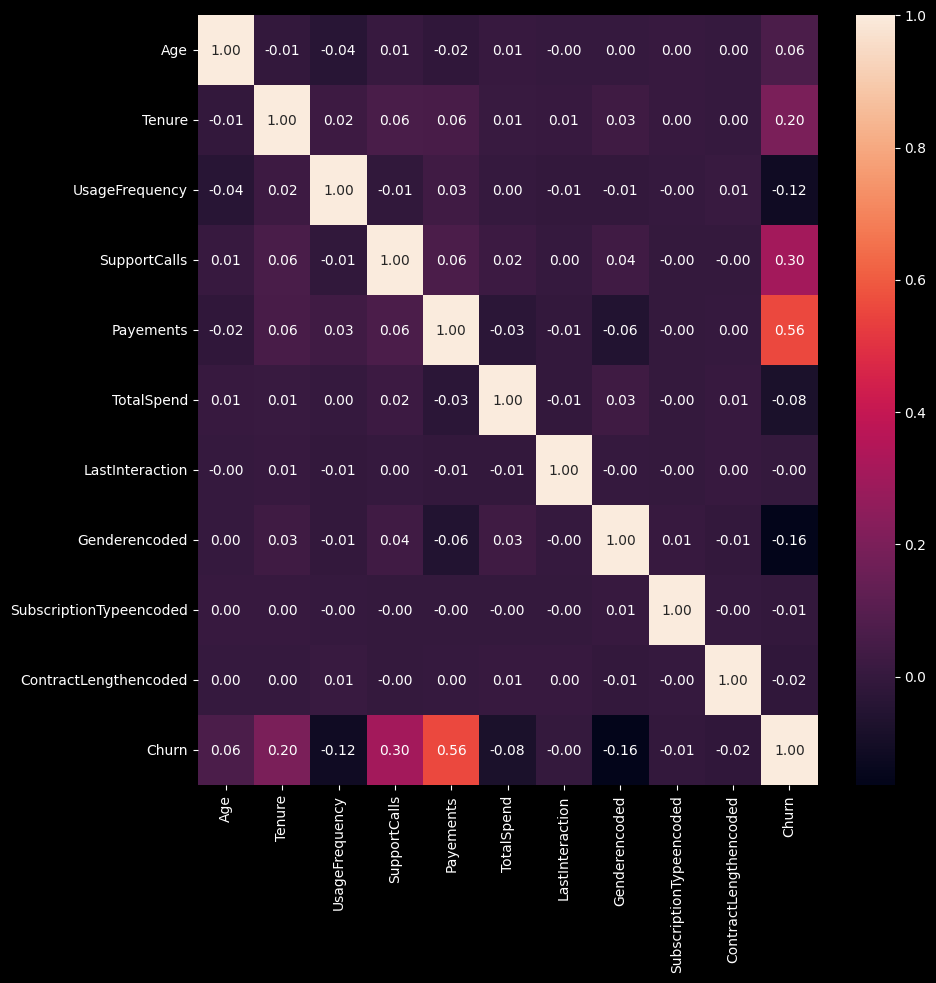

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(df4.corr(method='pearson'),annot=True,fmt='.2f',cbar=True)
plt.xlabel("")
plt.show()

In [30]:
x=df4.iloc[:,:-1]
y=df4.iloc[:,-1]

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
x_train.columns

Index(['Age', 'Tenure', 'UsageFrequency', 'SupportCalls', 'Payements',
       'TotalSpend', 'LastInteraction', 'Genderencoded',
       'SubscriptionTypeencoded', 'ContractLengthencoded'],
      dtype='object')

In [33]:
x.columns.to_list()

['Age',
 'Tenure',
 'UsageFrequency',
 'SupportCalls',
 'Payements',
 'TotalSpend',
 'LastInteraction',
 'Genderencoded',
 'SubscriptionTypeencoded',
 'ContractLengthencoded']

In [34]:
x.describe()

,Age,Tenure,UsageFrequency,SupportCalls,Payements,TotalSpend,LastInteraction,Genderencoded,SubscriptionTypeencoded,ContractLengthencoded
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.466353,1.000792,0.991052
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.498870,0.816854,0.810036
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000,0.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000,1.000000,1.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000,2.000000,2.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000,2.000000,2.000000


In [35]:
class1=LogisticRegression(solver='liblinear')
class1


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
class1_cross=cross_val_score(class1,x,y,scoring='accuracy',cv=10,n_jobs=-1)
print(class1_cross)
mean_value=np.mean(class1_cross)
print(mean_value)

[0.82649891 0.82634358 0.82618826 0.8258776  0.82911294 0.82631661
 0.82507379 0.82336492 0.82849153 0.81668479]
0.8253952942619757


In [37]:

class2=DecisionTreeClassifier(splitter='best',max_depth=10,min_samples_leaf=10,max_features='sqrt',criterion='entropy',min_samples_split=100)
class2

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the

In [38]:
class2_cross=cross_val_score(class2,x,y,scoring='accuracy',cv=10,n_jobs=-1)
print(class2_cross)
mean_value1=np.mean(class2_cross)
print(mean_value1)

[0.95495495 0.95495495 0.97607953 0.97623486 0.96426907 0.97188131
 0.95727824 0.96504583 0.96722076 0.95914246]
0.9647061950552548


In [39]:

class3=RandomForestClassifier(n_estimators=30,max_depth=10,min_samples_split=100,max_features='sqrt',n_jobs=-1,criterion='gini')
class3

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [40]:
class3_cross=cross_val_score(class3,x,y,scoring='accuracy',cv=10,n_jobs=-1)
print(class3_cross)
mean_value2=np.mean(class3_cross)
print(mean_value1)

[0.99502951 0.99518484 0.9954955  0.99596148 0.99440733 0.99347522
 0.99627156 0.99533944 0.99627156 0.99502874]
0.9647061950552548


In [41]:
data_dict={
    'logistic_classification':class1,
    'decisontree_classification':class2,
    'randomforest_classification':class3
}

In [43]:
class1.fit(x_train,y_train)
y_logistic=class1.predict(x_test)
print(y_logistic)
print("score is logistic ",class1.score(x_test,y_logistic))
print(classification_report(y_test,y_logistic))
print("===============================================")


[0 0 1 ... 1 0 0]
score is logistic  1.0
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [44]:
class2.fit(x_train,y_train)
y_decesion=class2.predict(x_test)
print(y_decesion)
print("score is ",class2.score(x_test,y_decesion))
print(classification_report(y_test,y_decesion))


[0 0 1 ... 1 1 0]
score is  1.0
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      6793
           1       0.93      0.96      0.94      6082

    accuracy                           0.94     12875
   macro avg       0.94      0.94      0.94     12875
weighted avg       0.94      0.94      0.94     12875



In [ ]:
class3.fit(x_train,y_train)
print("==========================================")
y_random=class3.predict(x_test)
print(y_random)
print("score is ",class3.score(x_test,y_random))
print(classification_report(y_test,y_random))

In [ ]:
import joblib

joblib.dump(class1,"class1.joblib")

['class1.joblib']

In [ ]:
joblib.dump(class2,"class2.joblib")

['class2.joblib']

In [ ]:
joblib.dump(class3,"class3.joblib")

['class3.joblib']

In [ ]:
if x.shape[0] == y.shape[0] and x_train.shape[0] == y_train.shape[0]:
    print("shapes are equal")
else:
    print("shapes are unequal")

shapes are equal


In [ ]:
assert x_train.shape[0] == y_train.shape[0], "shape is equal"

In [ ]:
important_features=SelectKBest(score_func=f_classif,k=8)
important_features.fit(x,y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...0024518B42B60>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8


In [ ]:
features=x.columns[important_features.get_support()]
features

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Gender_encoded', 'Contract_Length_encoded'],
      dtype='object')

In [ ]:
spearman=df3.corr(method='spearman').round(2)
print(spearman)

                            Age  Tenure  Usage Frequency  Support Calls  \
Age                        1.00   -0.01            -0.04           0.00   
Tenure                    -0.01    1.00             0.02           0.06   
Usage Frequency           -0.04    0.02             1.00          -0.01   
Support Calls              0.00    0.06            -0.01           1.00   
Payment Delay             -0.02    0.05             0.03           0.06   
Subscription Type          0.00    0.00            -0.00          -0.00   
Total Spend                0.01    0.01             0.00           0.02   
Last Interaction          -0.00    0.01            -0.01           0.00   
Gender_encoded             0.00    0.03            -0.01           0.03   
Subscription_Type_encoded  0.00    0.00            -0.00          -0.00   
Contract_Length_encoded   -0.00    0.00             0.01          -0.00   
Churn                      0.06    0.19            -0.12           0.30   

                        

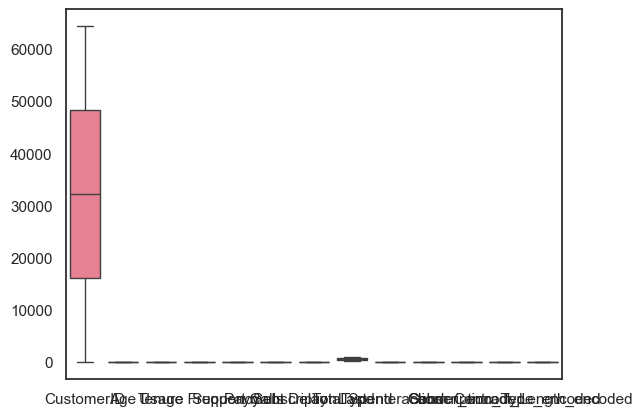

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.set_theme(style='white',palette=cl1)
sns.boxplot(df3)
plt.show()